In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# ==========================================
# 1. MENYIAPKAN DATASET BARU
# ==========================================
# Kita membuat dataset tiruan yang realistis: Hubungan Jumlah Kamar vs Harga Rumah
np.random.seed(42)
jumlah_kamar = np.random.normal(5, 1, 150).reshape(-1, 1) # Rata-rata 5 kamar
# Harga rumah dipengaruhi jumlah kamar + noise acak
harga_rumah = 100 + 50 * jumlah_kamar + np.random.normal(0, 30, (150, 1)) 

# Konversi ke DataFrame Pandas agar lebih rapi saat dianalisis
data = pd.DataFrame({
    'Jumlah_Kamar': jumlah_kamar.flatten(),
    'Harga_Rumah': harga_rumah.flatten()
})

print("--- 5 Data Pertama ---")
print(data.head())
print("\n" + "="*40 + "\n")

--- 5 Data Pertama ---
   Jumlah_Kamar  Harga_Rumah
0      5.496714   382.350493
1      4.861736   353.480231
2      5.647689   361.983685
3      6.523030   433.119104
4      4.765847   347.084505




In [3]:
# ==========================================
# 2. PEMBAGIAN DATA (TRAIN & TEST SPLIT)
# ==========================================
# Membagi data menjadi 80% untuk pelatihan dan 20% untuk pengujian
X = data[['Jumlah_Kamar']]
y = data['Harga_Rumah']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Jumlah data latih: {len(X_train)}")
print(f"Jumlah data uji: {len(X_test)}")
print("\n" + "="*40 + "\n")

Jumlah data latih: 120
Jumlah data uji: 30




In [ ]:
# ==========================================
# 3. PELATIHAN MODEL (TRAINING)
# ==========================================
# Inisialisasi dan latih model Linear Regression
model_regresi = LinearRegression()
model_regresi.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [5]:
# ==========================================
# 4. PREDIKSI DAN EVALUASI
# ==========================================
# Membuat prediksi menggunakan data uji
y_pred = model_regresi.predict(X_test)

# Menghitung performa model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- Hasil Evaluasi Model ---")
print(f"Koefisien (Kemiringan): {model_regresi.coef_[0]:.2f}")
print(f"Intercept (Konstanta): {model_regresi.intercept_:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared Score: {r2:.2f} (Model menjelaskan {(r2*100):.1f}% variasi data)")

--- Hasil Evaluasi Model ---
Koefisien (Kemiringan): 50.85
Intercept (Konstanta): 98.60
Mean Squared Error (MSE): 747.30
R-squared Score: 0.66 (Model menjelaskan 66.4% variasi data)


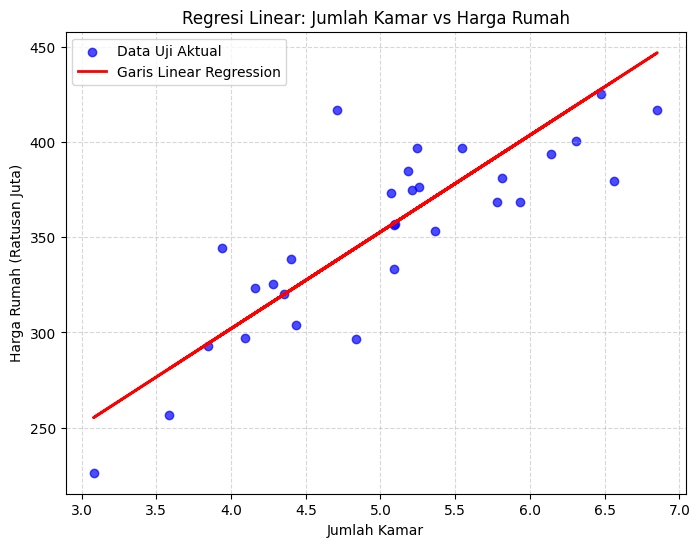

In [6]:
# ==========================================
# 5. VISUALISASI HASIL REGRESI
# ==========================================
plt.figure(figsize=(8, 6))

# Plot titik data asli untuk pengujian
plt.scatter(X_test, y_test, color='blue', alpha=0.7, label='Data Uji Aktual')

# Plot garis regresi hasil prediksi
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Garis Linear Regression')

plt.title('Regresi Linear: Jumlah Kamar vs Harga Rumah')
plt.xlabel('Jumlah Kamar')
plt.ylabel('Harga Rumah (Ratusan Juta)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Menampilkan grafik di VS Code
plt.show()